In [1]:
!pip install missingno
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import missingno as msno

df = sns.load_dataset('titanic')
df_working = df.copy()


### Step 1 — Visualize missing patterns
Missingno bar + matrix

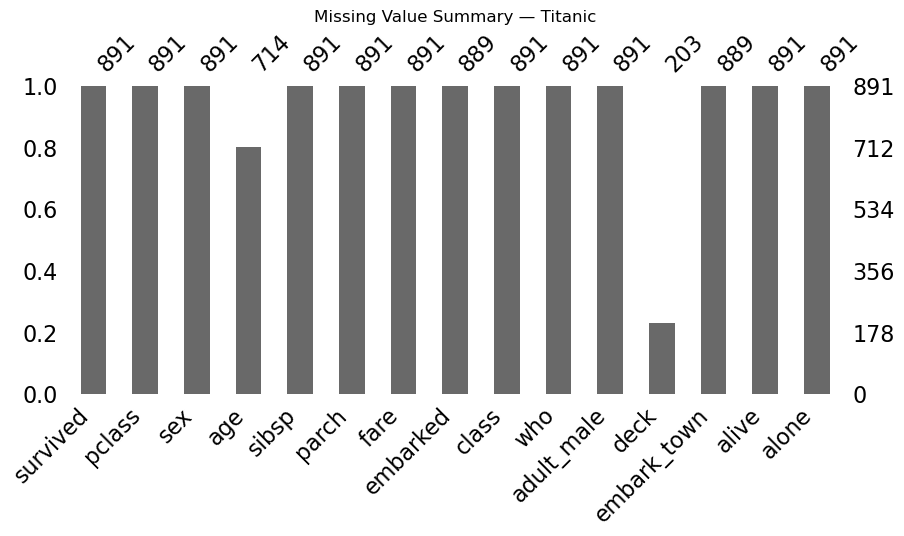

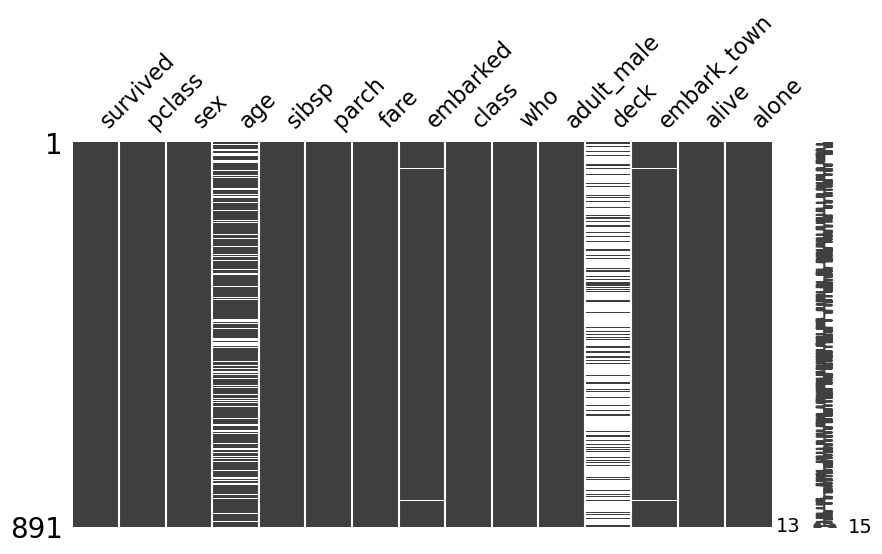

In [2]:

msno.bar(df_working, figsize=(10, 4))
plt.title('Missing Value Summary — Titanic')
plt.show()

msno.matrix(df_working, figsize=(10, 5))
plt.show()


### Step 2 — Drop high-missingness columns
Drop columns >30% missing

In [3]:
thresh = 0.3
missing_pct = df_working.isnull().mean()
high_missing = missing_pct[missing_pct > thresh].index.tolist()
print('Columns to drop:', high_missing)
df_working = df_working.drop(columns=high_missing)
print('New shape:', df_working.shape)


Columns to drop: ['deck']
New shape: (891, 14)


### Step 3 — Median imputation (numeric)
Fill missing age with median

In [5]:

age_median = df_working['age'].median()
print(f'Age median: {age_median}')
df_working['age'] = df_working['age'].fillna(age_median)
print('Missing in age after imputation:', df_working['age'].isnull().sum())


Age median: 28.0
Missing in age after imputation: 0


### Step 4 — Mode imputation (categorical)
Fill missing embarked with mode

In [6]:

embarked_mode = df_working['embarked'].mode()[0]
print(f'Embarked mode: {embarked_mode}')
df_working['embarked'] = df_working['embarked'].fillna(embarked_mode)
print('Missing in embarked:', df_working['embarked'].isnull().sum())


Embarked mode: S
Missing in embarked: 0


### Step 5 — IQR outlier detection
Detect outliers in fare

In [7]:
Q1 = df_working['fare'].quantile(0.25)
Q3 = df_working['fare'].quantile(0.75)
IQR = Q3 - Q1
lower_fence = Q1 - 1.5 * IQR
upper_fence = Q3 + 1.5 * IQR
outliers = df_working[(df_working['fare'] < lower_fence) | (df_working['fare'] > upper_fence)]
print(f'Outliers: {len(outliers)} ({len(outliers)/len(df_working)*100:.1f}%)')
print(f'Lower fence: {lower_fence:.2f} | Upper fence: {upper_fence:.2f}')

Outliers: 116 (13.0%)
Lower fence: -26.72 | Upper fence: 65.63


### Step 6 — Winsorization
Cap outliers instead of dropping

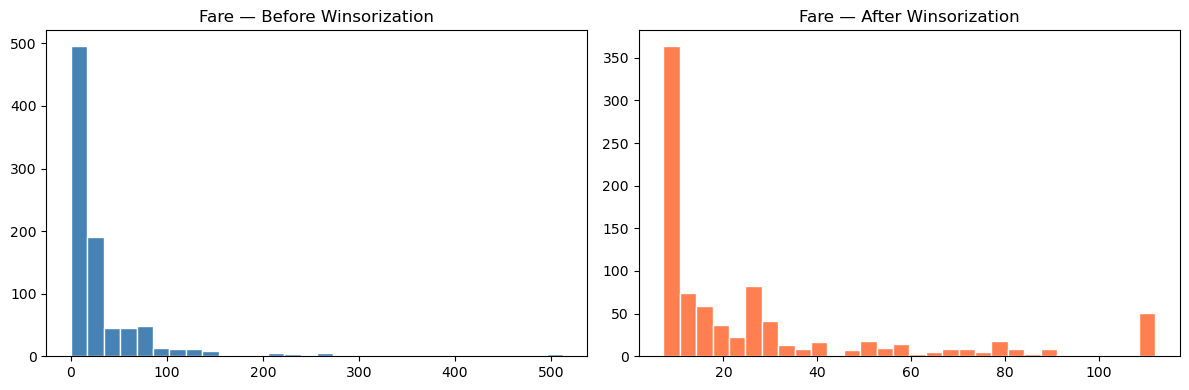

In [8]:

p5 = df_working['fare'].quantile(0.05)
p95 = df_working['fare'].quantile(0.95)
df_working['fare_capped'] = df_working['fare'].clip(lower=p5, upper=p95)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df_working['fare'], bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('Fare — Before Winsorization')
axes[1].hist(df_working['fare_capped'], bins=30, color='coral', edgecolor='white')
axes[1].set_title('Fare — After Winsorization')
plt.tight_layout()
plt.show()